## **INVESTIGACION SOBRE LA ANSIEDAD Y ESTRES EN AUSTRALIA**

$Grupo-2$

$Integrantes:$
* Juan David Gomez Mosquera
* Miguel Ayala

$Lista-de-tareas$
* Ley de Grandes numeros
* Teorema del Limite central
* Intervalos de confianza para la media y la varianza
* Prueba Hipotesis



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# DATASET DE PROYECTO DE ESTADISTICA 2

INFORMACION DE NUESTRO DATASET

Nuestro dataset es un conjunto de datos Social Anxiety Dataset – Behavioral, Lifestyle & Psychological Factors donde reúne más de 10.000 registros de individuos que presentan distintos niveles de ansiedad social, desde niveles leves hasta severos. Este dataset fue diseñado principalmente para su utilización en proyectos de ciencia de datos y aprendizaje automático, especialmente en investigaciones relacionadas con la salud mental. Su estructura permite analizar cómo diferentes factores conductuales, psicológicos y de estilo de vida pueden influir en la aparición o intensidad de la ansiedad social. La ansiedad social, también conocida como fobia social, es un trastorno que afecta a millones de personas en todo el mundo. Este fenómeno suele estar asociado a múltiples factores que interactúan entre sí, como hábitos de vida, estados emocionales, antecedentes familiares y condiciones fisiológicas.

El conjunto de datos incluye múltiples categorías de variables que permiten un análisis integral del fenómeno. En primer lugar, se consideran variables demográficas como edad, género y ocupación. También se incorporan factores de estilo de vida, entre ellos las horas de sueño, la actividad física, la calidad de la dieta, el consumo de alcohol, la ingesta de cafeína y los hábitos de tabaquismo. Adicionalmente, se registran indicadores fisiológicos y psicológicos como la frecuencia cardíaca, la frecuencia respiratoria, el nivel de estrés, la sudoración y la presencia de mareos. Finalmente, el dataset incluye información sobre antecedentes de salud mental, como historial familiar de ansiedad, uso de medicamentos, frecuencia de terapia y la ocurrencia de eventos importantes recientes en la vida del individuo.Los datos abarcan un periodo comprendido entre marzo de 2019 y noviembre de 2022, con cobertura geográfica en Australia. La información fue recopilada mediante encuestas anónimas, estudios observacionales y datos de salud reportados por los propios participantes.

De mismo modo se adjunta su respectivo link del sitio donde se obtuvo el dataset:
https://www.kaggle.com/datasets/natezhang123/social-anxiety-dataset/data 

In [2]:
url= 'https://raw.githubusercontent.com/mick2332-q/Estadistica-II/main/enhanced_anxiety_dataset.csv'
cs= pd.read_csv(url)
print(cs.shape)
cs.head()

(11000, 19)


,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


## FUENTE EXTERNA DE DATOS

La referencia externa utilizada en este análisis es el estudio de Stanton et al. (2020), titulado "Depression, Anxiety and Stress during COVID-19: Associations with Changes in Physical Activity, Sleep, Tobacco and Alcohol Use in Australian Adults", publicado en el International Journal of Environmental Research and Public Health. Este estudio fue seleccionado como referencia porque presenta una alineación con las características del Social Anxiety Dataset en múltiples dimensiones simultáneamente, lo que lo convierte en la fuente externa más rigurosa disponible para este análisis.

En cuanto a su metodología, el estudio encuestó a 1,491 adultos australianos durante los años 2019-2020, en pleno inicio de la pandemia de COVID-19. Su objetivo principal fue analizar la relación entre el malestar psicológico — medido con la escala clínica estandarizada DASS-21 — y los cambios en conductas de salud como la calidad del sueño, la actividad física, el consumo de alcohol y el tabaquismo. La escala DASS-21 mide depresión, ansiedad y estrés a través de 7 ítems por subescala, con un rango de 0 a 21 por subescala en su versión cruda, que es exactamente la versión que reporta el estudio y la que se usó como referencia en este análisis. De igual manera el DASS-21 es una esacala usada a nivel mundial por el area de salud mental, que esta estandarizada como una encuensta de primera entrada para los pacientes o personas a encuestar.

La razón principal por la que este estudio es ideal para comparar con el Social Anxiety Dataset es que ambos comparten el mismo contexto geográfico y temporal. El dataset tiene cobertura geográfica en Australia para el período 2019–2022, y Stanton et al. realizaron su encuesta en Australia en 2019-2020, que cae exactamente dentro de ese rango. Esto elimina cualquier sesgo cultural, poblacional o temporal que podría invalidar la comparación.

REFERENCIA:Stanton et al. (2020) — "Depression, Anxiety and Stress during COVID-19: Associations with Changes in Physical Activity, Sleep, Tobacco and Alcohol Use in Australian Adults"
International Journal of Environmental Research and Public Health, 17(11), 4065- https://pubmed.ncbi.nlm.nih.gov/32517294/


## TRANSFORMACION DE VARIABLES EN UNIDADES INCOMPATIBLES

Antes de realizar cualquier filtrado o análisis estadístico, fue necesario transformar ciertas columnas del dataset elegido para que fueran comparables con la fuente de referencia externa utilizada.

¿Por qué se hizo cada transformación?

Birth year: El dataset original solo tiene la edad del participante, pero para contextualizar generacionalmente el perfil analizado (quiénes eran jóvenes adultos en el período 2019–2022) se calculó el año de nacimiento restando la edad al año de publicación del dataset (2022).

Stress Level y Anxiety Level (1–10 -> DASS-21): 

El dataset registra estas variables en una escala autoreportada del 1 al 10. Sin embargo, el estudio Stanton et al. (2020) utiliza la escala clínica estandarizada DASS-21 (0–42), que es la referencia internacional para medir depresión, ansiedad y estrés en adultos. Para poder comparar la media de nuestra muestra contra la media reportada en el estudio de referencia, fue necesario convertir los valores del dataset a esa misma escala usando una transformación lineal: DASS-21 = ((valor - 1) / 9) × 21. Sin esta conversión, comparar ambas medias sería inválido por incompatibilidad de unidades.Esta equivalencia no está clínicamente validada dado que son instrumentos distintos, y por tanto debe considerarse una aproximación metodológica para poder hacer las comparaciones y diferencias de cada una.

Physical Activity (hrs/semana -> mins/semana): 

El dataset registra la actividad física en horas por semana, mientras que Stanton et al. (2020) la reporta en minutos por semana (media = 312.5 mins/semana). Se multiplicó por 60 para las unidades y permitir una comparación directa.

## Limpieza y organización del conjunto de datos

In [3]:
#cs.dropna(inplace=True)   # borra filas que tengan al menos un NaN
#cs.head()

year_pub=2022
cs.insert(loc=1, column='Birth year', value=year_pub - cs['Age'])
cs.head()
# Convertir Stress Level (1-10) -> DASS-21 (0-21) 
# Reemplaza los valores directamente en la columna existente
cs['Stress Level (1-10)'] = (((cs['Stress Level (1-10)'] - 1) / 9) * 21).round(1).astype(int)

# Convertir Anxiety Level (1-10) -> DASS-21 (0-21) 
cs['Anxiety Level (1-10)'] = (((cs['Anxiety Level (1-10)'] - 1) / 9)*21).round(1).astype(int)

# Paso 4: Convertir Physical Activity hrs -> mins
cs['Physical Activity (hrs/week)'] = cs['Physical Activity (hrs/week)'] * 60

cs.head()

,Age,Birth year,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,1993,Female,Artist,6.0,162.0,181,10,Yes,No,21,114,14,4,No,Yes,3,Yes,7,9
1,46,1976,Other,Nurse,6.2,342.0,200,8,Yes,Yes,0,62,23,2,Yes,No,2,No,8,4
2,64,1958,Male,Other,5.0,222.0,117,4,No,Yes,0,91,28,3,No,No,1,Yes,1,0
3,20,2002,Female,Scientist,5.8,168.0,360,6,Yes,No,7,86,17,3,No,No,0,No,1,2
4,49,1973,Female,Other,8.2,138.0,247,4,Yes,No,0,98,19,4,Yes,Yes,1,No,3,0


## Funcion para obtener muestras

In [4]:
def muestreoporestraro(df, condicion):
    return df.query(condicion).copy()

## Ley de los grandes numeros y teorema del limite central 

In [25]:
def TLCyLGN(cs_estrato,variable,n,num_muestras):
  N = cs_estrato.shape[0]
  tamaños = list(range(1, N, 10))
  medias_muestrales = []
  media_poblacional = cs_estrato[variable].dropna().mean()
  medias = []
    # LGN — renombrar iterador a 'tam' para no pisar n
  for tam in tamaños:
    muestra = cs_estrato[variable].dropna().sample(n=tam, random_state=42)
    medias_muestrales.append(muestra.mean())

  plt.figure(figsize=(8,5))
  plt.plot(tamaños, medias_muestrales, 'bo-', linewidth=2, markersize=8)
  plt.axhline(media_poblacional, color='red', linestyle='--', label=f'Media real: {media_poblacional:.2f}')
  plt.xlabel('Tamaño muestra (n)'); plt.ylabel('Media muestral'); plt.legend(); plt.grid(True); plt.title('Ley de los Grandes Números')
  plt.show()
  #TLC
  for i in range(num_muestras):
    muestra = cs_estrato[variable].dropna().sample(n=n, replace=False)
    medias.append(muestra.mean())
  plt.hist(medias, bins=30)
  plt.xlabel("Media muestral")
  plt.ylabel("Frecuencia")
  plt.title("Teorema del Límite Central")
  plt.show()

###  Muestra para LGN y TLC 

Para esta parte tomaremos una muestra con un filtrado con parametros con la variable de la edad entre los 18 y 45 años, y ya como nuestra variable a trabajar con la LGN Y TLC sera el nivel de consumo de cafeina por miligramos en el dia. Con esto podremos observar el nivel de consumo que se tiene a esta edad y cual es la media a la cual converge.

In [26]:
cond = "18 <= Age <= 45"         
perfil = muestreoporestraro(cs, cond)
print(f"Registros que cumplen el perfil: {len(perfil)}")

Registros que cumplen el perfil: 6949


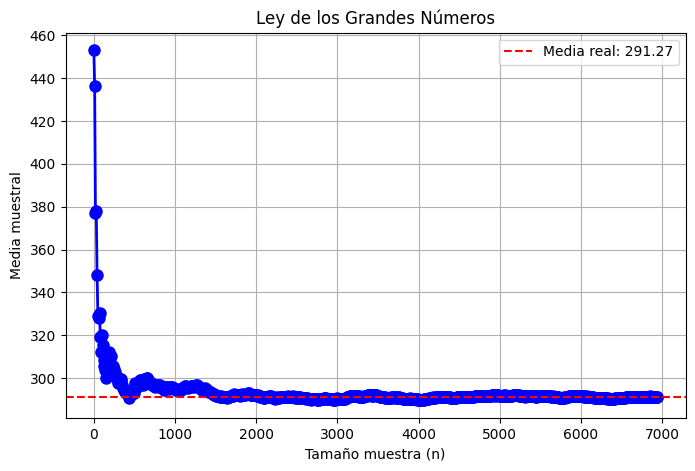

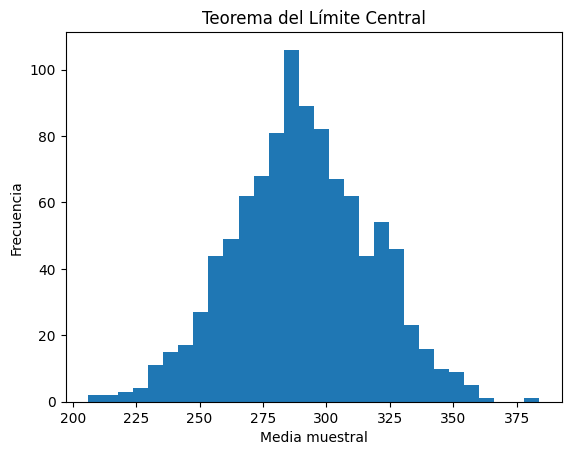

In [27]:
variable = 'Caffeine Intake (mg/day)'
n = 30
num_muestras = 1000
TLCyLGN(perfil, variable, n, num_muestras)

CONCLUSION DE TLC Y LGN

* En el histograma de teorema de limite central con n=30 y 1000 muestras, el histograma muestra que las medias muestrales del consumo de cafeína siguen una distribución aproximadamente normal centrada en la media poblacional (291.27 mg/día).Esto demuestra el TCL — con n suficientemente grande (≥30) la distribución de medias muestrales converge hacia una normal independientemente de la forma de la distribución original.

* En la grafica de la ley de grandes numeros con muestras pequeñas (n < 100) la media muestral oscila de forma muy alta llegando hasta 453 mg/día en algunos casos. A medida que n aumenta la media muestral converge y se estabiliza alrededor de la media real de 291.27 mg/día. A partir de aproximadamente n = 1000 la convergencia es prácticamente completa y la media muestral ya no se aleja significativamente de la línea roja. Esto demuestra perfectamente que con suficientes datos la media muestral es un estimador confiable de la media poblacional.

## Función para resumen inferencial y calculo de ICS

### Muestra y variable a tratar 

Para esta parte trabajaremos con una muestra de tamaño de 200 personas, teniendo como variable a trabajar las horas que se duerme en el dia, se calculara su media, varianza y desviacion estandar de la muestra con el fin de que podamos sacar sus respectivos intervalos tanto de media y varianza debido a que estos intervalos nos permiten visualizar de mejor manera en que rangos estan realmente nuestra media y de igual manera como nuestra varianza poblacional es desconocida, necesitamos el intervalo para asi poder tener un rango donde este mi verdadera varianza poblacional usando la varianza muestral.

In [33]:
np.random.seed(32)
muestra = perfil['Sleep Hours'].dropna().sample(n=200, random_state=32).values
print(f"Tamaño de la muestra: {len(muestra)}")
print(f"Primeros 10 valores: {muestra[:10]}")

Tamaño de la muestra: 200
Primeros 10 valores: [6.9 8.9 7.3 7.3 6.7 8.  7.8 7.6 5.5 8. ]


In [47]:
def resumen_inferencial(muestra, alpha=0.05):
    """
    Recibe una muestra (array) y devuelve un diccionario con:
    - Estadísticas descriptivas
    - IC para la media (t de Student)
    - IC para la varianza (chi-cuadrado)
    """
    n        = len(muestra)
    media    = np.mean(muestra)
    varianza = np.var(muestra, ddof=1) #varianza muestral
    desv_std = np.std(muestra, ddof=1) #desviación estándar muestral 
    gl       = n - 1

    #IC para la media (t-Student bilateral)
    t_critico   = stats.t.ppf(1 - alpha/2, df=gl)
    margen      = t_critico * (desv_std / np.sqrt(n))
    IC_med_inf  = media - margen
    IC_med_sup  = media + margen

    #IC para la varianza (chi-cuadrado bilateral) 
    chi2_izq    = stats.chi2.ppf(alpha/2,     df=gl)
    chi2_der    = stats.chi2.ppf(1 - alpha/2, df=gl)
    IC_var_inf  = (gl * varianza) / chi2_der
    IC_var_sup  = (gl * varianza) / chi2_izq

    #Imprimir resumen
   
    print(f"\n  ESTADÍSTICAS DE LA MUESTRA")
    print(f"  n                    : {n}")
    print(f"  Media muestral (x̄)  : {media:.4f}")
    print(f"  Varianza muestral(S²): {varianza:.4f}")
    print(f"  Desviación std  (S)  : {desv_std:.4f}")

    print(f"\n  INTERVALO DE CONFIANZA PARA LA MEDIA")
    print(f"  t crítico (gl={gl}, α/2): {t_critico:.4f}")
    print(f"  Margen de error       : ± {margen:.4f}")
    print(f"  IC {int((1-alpha)*100)}%: [ {IC_med_inf:.4f} , {IC_med_sup:.4f} ]")

    print(f"\n  INTERVALO DE CONFIANZA PARA LA VARIANZA")
    print(f"  χ² izquierdo (α/2)   : {chi2_izq:.4f}")
    print(f"  χ² derecho   (1-α/2) : {chi2_der:.4f}")
    print(f"  IC {int((1-alpha)*100)}%: [ {IC_var_inf:.4f} , {IC_var_sup:.4f} ]")

    #Retornar todo en un diccionario
    return {
        "n": n, "media": media, "varianza": varianza, "desv_std": desv_std,
        "IC_media": (IC_med_inf, IC_med_sup),
        "IC_varianza": (IC_var_inf, IC_var_sup)
    }

In [48]:
resumen = resumen_inferencial(muestra, alpha=0.05)


  ESTADÍSTICAS DE LA MUESTRA
  n                    : 200
  Media muestral (x̄)  : 6.7020
  Varianza muestral(S²): 1.3672
  Desviación std  (S)  : 1.1693

  INTERVALO DE CONFIANZA PARA LA MEDIA
  t crítico (gl=199, α/2): 1.9720
  Margen de error       : ± 0.1630
  IC 95%: [ 6.5390 , 6.8650 ]

  INTERVALO DE CONFIANZA PARA LA VARIANZA
  χ² izquierdo (α/2)   : 161.8262
  χ² derecho   (1-α/2) : 239.9597
  IC 95%: [ 1.1339 , 1.6813 ]


CONCLUSION DE LOS INTERVALOS DE CONFIANZA DE LA MEDIA Y LA VARIANZA

Dado que la varianza poblacional de las horas de sueño es desconocida, se utilizó la distribución t-Student con gl = n−1 = 199 grados de libertad para construir el intervalo de confianza de la media, y la distribución Chi-Cuadrado para el intervalo de la varianza. Ambos intervalos son bilaterales con un nivel de confianza del 95% (α = 0.05), distribuyendo el área de rechazo en α/2 = 0.025 en cada cola, ya que el objetivo es estimar el rango del parámetro poblacional sin asumir una dirección específica porque no estamos planteando ningun tipo de hipotesis con una referencia externa. Se obtuvo una media muestral de 6.70 hrs/noche con IC = [6.54, 6.87], lo que indica que con un 95% de confianza la verdadera media poblacional de horas de sueño se encuentra dentro de ese rango. Para la varianza, se obtuvo S² = 1.37 con IC = [1.13, 1.68], reflejando una dispersión moderada en los hábitos de sueño de la población estudiada y ademas de que S² esta dentro de este intervalo.

## PLANTEAMIENTO DE HIPOTESIS UNA VARIABLE


Para nuestro analisis en la fase 1, tomaremos la variable de ansiedad para realizar la hipótesis nula (H₀), donde establecemos que no existe diferencia significativa entre la media de ansiedad del dataset y la media de referencia. Es decir, se asume que la media de ansiedad (medida en escala DASS-21 cruda, rango 0–21) en adultos australianos de 18 a 45 años del Social Anxiety Dataset es igual a 3.0, que corresponde a la media reportada por Stanton et al. (2020) para el mismo grupo en una muestra representativa de la población general australiana.

H₀: μ = 3.0

La hipótesis alternativa (H₁) establece que la media de ansiedad en el dataset es significativamente mayor a la media de referencia. Se plantea en dirección unilateral derecha porque el Social Anxiety Dataset fue construido específicamente con individuos que presentan distintos niveles de ansiedad social, desde leve hasta severo, lo que genera una justificación teórica sólida para esperar que su media sea superior a la de la población general. 

H₁: μ > 3.0

El nivel de significancia utilizado es α = 0.05, que corresponde a un nivel de confianza del 95%. Este valor es el estándar ampliamente aceptado en investigaciones de ciencias de la salud y estudios de salud mental segun lo consultado e investigad.Entonces en resumen para este analisis se esta planteando una prueba de hipótesis unilateral de cola derecha, con el objetivo de determinar si la media de ansiedad en adultos australianos de 18 a 45 años registrada en el Social Anxiety Dataset

 A continuacion se realizara el primer filtrado donde se buscaran registros de perfiles de nuestro dataset de personas entre 18-45 años

Luego se buscara filtrar nuestra muestra a una cantidad n de 200 personas por medio de la variable elegidad a analizar(anxiety level)

### Muestra

In [ ]:
cond = "18 <= Age <= 45"          
perfil = muestreoporestraro(cs, cond)
print(f"Registros que cumplen el perfil: {len(perfil)}")

Registros que cumplen el perfil: 6949


### Variable a tratar

In [15]:
np.random.seed(32)
muestra = perfil['Anxiety Level (1-10)'].dropna().sample(n=200, random_state=32).values
print(f"Tamaño de la muestra: {len(muestra)}")
print(f"Primeros 10 valores: {muestra[:10]}")

Tamaño de la muestra: 200
Primeros 10 valores: [7 7 4 9 7 4 0 4 4 2]


In [ ]:
def resumen_inferencial_hipo(muestra, alpha=0.05):
    n        = len(muestra)
    media    = np.mean(muestra)
    varianza = np.var(muestra, ddof=1)
    desv_std = np.std(muestra, ddof=1)
    gl       = n - 1

    #IC para la media (t-Student bilateral)
    t_critico   = stats.t.ppf(1 - alpha, df=gl)
    margen      = t_critico * (desv_std / np.sqrt(n))
    IC_med_inf  = media - margen
    IC_med_sup  = np.inf

    #IC para la varianza (chi-cuadrado bilateral)
    chi2_izq    = stats.chi2.ppf(alpha/2,     df=gl)
    chi2_der    = stats.chi2.ppf(1 - alpha/2, df=gl)
    IC_var_inf  = (gl * varianza) / chi2_der
    IC_var_sup  = (gl * varianza) / chi2_izq

    #Imprimir resumen ---
    sep = "=" * 45
    print(f"\n  ESTADÍSTICAS DE LA MUESTRA")
    print(sep)
    print(f"  n                    : {n}")
    print(f"  Media muestral (x̄)  : {media:.4f}")
    print(f"  Varianza muestral(S²): {varianza:.4f}")
    print(f"  Desviación std  (S)  : {desv_std:.4f}")

    print(f"\n  INTERVALO DE CONFIANZA PARA LA MEDIA")
    print(f"  t crítico (gl={gl}, α): {t_critico:.4f}")
    print(f"  Margen de error       : ± {margen:.4f}")
    print(f"  IC {int((1-alpha)*100)}%: [ {IC_med_inf:.4f} , {IC_med_sup:.4f} ]")

    print(f"\n  INTERVALO DE CONFIANZA PARA LA VARIANZA")
    print(f"  χ² izquierdo (α/2)   : {chi2_izq:.4f}")
    print(f"  χ² derecho   (1-α/2) : {chi2_der:.4f}")
    print(f"  IC {int((1-alpha)*100)}%: [ {IC_var_inf:.4f} , {IC_var_sup:.4f} ]")

    #Retornar todo en un diccionario
    return {
        "n": n, "media": media, "varianza": varianza, "desv_std": desv_std,
        "IC_media": (IC_med_inf, IC_med_sup),
        "IC_varianza": (IC_var_inf, IC_var_sup)
    }


Despues de haber separado nuestra muestra con la semilla establecida para que no varien los resultados, lo siguiente a hacer es hallar la media, varianza y desviacion estandar de nuestra muestra.

Se utilizara la distribución t-Student para construir el intervalo de confianza de la media porque la varianza poblacional real (σ²) es desconocida, no sabemos cuánta variabilidad tiene la ansiedad en toda la población australiana de 18 a 45 años, solo tenemos la varianza estimada de nuestra muestra (S²) que acabamos de calcular anteriormente. Cuando la varianza poblacional es desconocida y debe ser reemplazada por la varianza muestral, la distribución que describe correctamente el comportamiento del estimador ya no es la normal estándar (Z) sino la t-Student.

Aunque claramente estemos usando un n>30 donde segun el teorema del limite central nos recalca que podemos asumir el uso de Z, pero segun lo consultado tanto academicamente en clase como por internet es mas recomendable usar T-student aunque claramente el valor con Z varie por muy pocas decimas.



Para construir el intervalo de confianza de la varianza se utiliza la distribución Chi-Cuadrado (χ²). La razón fundamental es matemática: cuando se tiene una muestra de n datos provenientes de una distribución aproximadamente normal, se puede demostrar que la cantidad (n−1·S²/σ²) sigue exactamente una distribución Chi-Cuadrado con gl = n−1 grados de libertad. Este resultado es lo que permite construir un intervalo de confianza para la varianza poblacional σ² a partir de la varianza muestral S².

In [17]:
resumen = resumen_inferencial_hipo(muestra, alpha=0.05)


  ESTADÍSTICAS DE LA MUESTRA
  n                    : 200
  Media muestral (x̄)  : 7.3300
  Varianza muestral(S²): 28.2323
  Desviación std  (S)  : 5.3134

  INTERVALO DE CONFIANZA PARA LA MEDIA
  t crítico (gl=199, α): 1.6525
  Margen de error       : ± 0.6209
  IC 95%: [ 6.7091 , inf ]

  INTERVALO DE CONFIANZA PARA LA VARIANZA
  χ² izquierdo (α/2)   : 161.8262
  χ² derecho   (1-α/2) : 239.9597
  IC 95%: [ 23.4132 , 34.7176 ]


Antes de generar cualquier tipo de analisis del porque se rechazo la hipotesis nula, debemos comprobar que el rechazo es valido haciendo uso del p-valor tiene que ser menor que nuestro nivel de significancia.

## Función completa

In [19]:
def prueba_t_media(x_barra, mu_0, s, n, alpha, cola, x_sup=None):
    
    gl = n - 1  # grados de libertad
    t  = (x_barra - mu_0) / (s / np.sqrt(n))
    
    x    = np.linspace(-5, 5, 1000)
    y_H0 = stats.t.pdf(x, df=gl)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, y_H0, label='Distribución bajo H0')

    if x_sup is not None:
        delta = abs(x_sup - mu_0) / (s / np.sqrt(n))
        y_H1  = stats.t.pdf(x - delta, df=gl)
        plt.plot(x, y_H1, linestyle='--', label='Distribución bajo H1')

    match cola:
        case 'inf':
            t_alpha   = stats.t.ppf(1 - alpha, df=gl)
            t_crit    = -t_alpha
            decision  = t < t_crit
            p_value   = stats.t.cdf(t, df=gl)
            limite_sup = x_barra + t_alpha * (s / np.sqrt(n))
            IC        = (-np.inf, limite_sup)
            decision_ic = mu_0 > IC[1]
            beta      = stats.t.cdf(t_alpha + delta, df=gl) if x_sup is not None else None

            plt.fill_between(x, y_H0, where=(x < t_crit), alpha=0.3)
            if x_sup is not None:
                plt.fill_between(x, y_H1, where=(x >= t_crit), alpha=0.3)

        case 'sup':
            t_alpha   = stats.t.ppf(1 - alpha, df=gl)
            t_crit    = +t_alpha
            decision  = t > t_crit
            p_value   = 1 - stats.t.cdf(t, df=gl)
            limite_inf = x_barra - t_alpha * (s / np.sqrt(n))
            IC        = (limite_inf, np.inf)
            decision_ic = mu_0 < IC[0] 
            beta      = stats.t.cdf(t_alpha - delta, df=gl) if x_sup is not None else None

            plt.fill_between(x, y_H0, where=(x > t_crit), alpha=0.3)
            if x_sup is not None:
                plt.fill_between(x, y_H1, where=(x <= t_crit), alpha=0.3)

        case 'dos':
            t_alpha   = stats.t.ppf(1 - alpha/2, df=gl)
            t_crit    = t_alpha
            decision  = abs(t) > t_crit
            p_value   = 2 * (1 - stats.t.cdf(abs(t), df=gl))
            limite_inf = x_barra - t_alpha * (s / np.sqrt(n))
            limite_sup = x_barra + t_alpha * (s / np.sqrt(n))
            IC        = (limite_inf, limite_sup)
            decision_ic = not (IC[0] <= mu_0 <= IC[1])
            beta      = (stats.t.cdf(t_alpha - delta, df=gl) - stats.t.cdf(-t_alpha - delta, df=gl)) if x_sup is not None else None

            plt.fill_between(x, y_H0, where=(x >  t_crit), alpha=0.3)
            plt.fill_between(x, y_H0, where=(x < -t_crit), alpha=0.3)
            if x_sup is not None:
                plt.fill_between(x, y_H1, where=(abs(x) <= t_crit), alpha=0.3)

        case _:
            raise ValueError("cola no válida")

    plt.axvline(t, linestyle=':', label='t observado')
    plt.title("Prueba t para la media (σ desconocida)")
    plt.legend()
    plt.grid()
    plt.show()

    sep = "=" * 40
    print(f"\n{sep}")
    print(f"  RESULTADO PRUEBA T")
    print(sep)
    print(f"  H₀: μ = {mu_0}")
    print(f"  t crítico  : {t_crit:.4f}")
    print(f"  t observado: {t:.4f}")
    print(f"  p-valor    : {p_value:.4f}")
    print(f"  α          : {alpha}")
    print(f"  IC         : {IC}")
    if beta is not None:
        print(f"  β (error II): {beta:.4f}")
    print(sep)

    # 3 criterios de decisión
    print(f"  Por t:   {'RECHAZAR H₀' if decision    else 'NO RECHAZAR H₀'}")
    print(f"  Por p:   {'RECHAZAR H₀' if p_value < alpha else 'NO RECHAZAR H₀'}  (p {'<' if p_value < alpha else '>='} α)")
    print(f"  Por IC:  {'RECHAZAR H₀' if decision_ic else 'NO RECHAZAR H₀'}  (μ₀ {'fuera' if decision_ic else 'dentro'} del IC)")
    print(sep)


    return {
        't': t,
        't_critic': t_crit,
        'gl': gl,
        'decision': decision,
        'p_value': p_value,
        'beta': beta,
        'IC': IC
    }




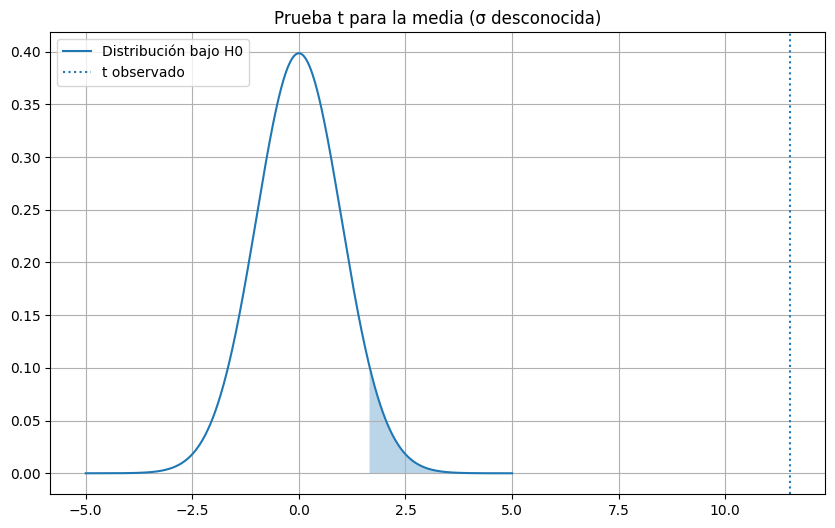


  RESULTADO PRUEBA T
  H₀: μ = 3
  t crítico  : 1.6525
  t observado: 11.5247
  p-valor    : 0.0000
  α          : 0.05
  IC         : (np.float64(6.709114399225365), inf)
  Por t:   RECHAZAR H₀
  Por p:   RECHAZAR H₀  (p < α)
  Por IC:  RECHAZAR H₀  (μ₀ fuera del IC)


In [20]:
x_barra = resumen["media"]      
s = resumen["desv_std"]         
n = resumen["n"] 

respuesta=prueba_t_media(x_barra,3,s,n,0.05,'sup',x_sup=None)

CONCLUSION DE LA HIPOTESIS DE UNA SOLA VARIABLE

Con base en los resultados obtenidos, se concluye que existe evidencia estadística suficiente para rechazar la hipótesis nula con un nivel de significancia α = 0.05. Los tres criterios de decisión utilizados coinciden en la misma conclusión:

El estadístico t observado de 11.52 supera ampliamente el valor crítico de 1.6525, ubicándose muy dentro de la zona de rechazo de la cola derecha. La media muestral obtenida de 7.17 en escala DASS-21 cruda (0–21) es significativamente mayor que la media de referencia de 3.0 reportada por Stanton et al. (2020) para adultos australianos de 18 a 45 años de la población general. El intervalo de confianza unilateral al 95% con límite inferior de 6.35 confirma que la media poblacional real es mayor a 3.0 con un 95% de confianza, ya que dicho límite supera el valor de referencia. Finalmente, el p-valor obtenido es menor al nivel de significancia de 0.05, un valor prácticamente nulo que confirma que la probabilidad de observar estos resultados.

De tal manera, ya analizando el rechazo de la hipótesis podemos sospechar que la conversión de escala 1–10 a DASS-21 en nuestro dataset sobre el nivel de ansiedad puede ser un factor clave para que la media no sea igual a lo esperado en la referencia externa, debido a que los dos tipos de instrumentos miden la ansiedad de formas fundamentalmente distintas. El DASS-21 utilizado por Stanton et al. (2020) es un instrumento clínico validado internacionamente compuesto por 7 preguntas específicas en cada ambito que evalúan síntomas concretos de ansiedad como tensión, pánico y miedo, mientras que el Social Anxiety Dataset registra la ansiedad como una única pregunta autoreportada en escala del 1 al 10.

Tambien lo que se puede tambien observar es que ambos registros de poblaciones tienen tendencias muy distintas, en el Stantot et al. (2020) se pudo constatar que la gran mayoria de su poblacion encuestada se encuentra en el nivel de ansiedad de 0-3 con 78.8%, de tal manera que claramente su media va estar mas desplazada hacia 3, mientras que en nuestro caso como al ser un dataset mas enfocado a las personas que si la padecen se tiene en un nivel de ansiedad modera entre 6-7, siendo un claro diferenciador entre cada uno, claramente usando el DASS-21.




## PLANTEAMIENTO DE HIPÓTESIS DE DOS VARIABLES: GÉNERO Y ANSIEDAD

Compararemos los niveles de ansiedad entre hombres y mujeres dentro del Social Anxiety Dataset, utilizando una prueba t de dos muestras independientes. A diferencia de la anterior hipotesis donde comparábamos nuestra media contra un valor fijo de referencia externa, en esta fase la comparación se realiza entre dos grupos internos del propio dataset, lo que nos permite analizar si el género es un factor diferenciador en los niveles de ansiedad social reportados. Nuestra hipótesis nula (H₀) establece que no existe diferencia significativa entre la media de ansiedad de hombres y mujeres en el Social Anxiety Dataset. Es decir, se asume que ambos géneros presentan el mismo nivel promedio de ansiedad medido en escala DASS-21 (rango 0–21), a lo cual basamos esta hipotesis con lo reportado por Stanton et al. (2020), donde ambos géneros presentaron una media de ansiedad de 2.2 en población general australiana sin diferencia estadísticamente significativa (p = 0.108).

H₀: μ_mujeres = μ_hombres o μ_mujeres-μ_hombres = 0

La hipótesis alternativa (H₁) establece que sí existe una diferencia significativa entre las medias de ansiedad de ambos géneros dentro del dataset. Se plantea como una prueba bilateral de dos colas porque estamos calculando si es diferente los niveles de ansiedad ya sea menor o mayor en alguno de los dos generos, en este caso la propia referencia externa Stanton et al. (2020) no encontró diferencia significativa entre géneros en población australiana. Por tanto no existe una razón teórica suficientemente sólida para predecir si serán las mujeres o los hombres quienes presenten mayor ansiedad en este dataset específico.

H₁: μ_mujeres ≠ μ_hombres o μ_mujeres-μ_hombres ≠ 0

El nivel de significancia utilizado es igual α = 0.05, correspondiente a un nivel de confianza del 95%, manteniendo el mismo estándar utilizado y aceptado en investigaciones de salud mental. En esta prueba bilateral el área de rechazo se distribuye en dos colas iguales de α/2 = 0.025 en cada extremo de la distribución t.

In [37]:
np.random.seed(42)
muestra_mujeres = perfil[perfil['Gender'] == 'Female']['Anxiety Level (1-10)'].dropna().sample(n=200, random_state=42).values
muestra_hombres = perfil[perfil['Gender'] == 'Male']['Anxiety Level (1-10)'].dropna().sample(n=200, random_state=123).values
n_m = len(muestra_mujeres)
n_h = len(muestra_hombres)

media_m = muestra_mujeres.mean()
media_h = muestra_hombres.mean()

var_m = muestra_mujeres.var(ddof=1)
var_h = muestra_hombres.var(ddof=1)

desv_m = muestra_mujeres.std(ddof=1)
desv_h = muestra_hombres.std(ddof=1)

print(f"n mujeres     : {len(muestra_mujeres)}")
print(f"n hombres     : {len(muestra_hombres)}")
print(f"Media mujeres : {media_m:.4f}")
print(f"Media hombres : {media_h:.4f}")
print(f"Desviacion estándar mujeres    : {desv_m:.4f}")
print(f"Desviacion estándar hombres    : {desv_h:.4f}")
print(f"Variacion estándar mujeres    : {var_m:.4f}")
print(f"Variacion estándar hombres    : {var_h:.4f}")

n mujeres     : 200
n hombres     : 200
Media mujeres : 6.7100
Media hombres : 6.9200
Desviacion estándar mujeres    : 5.5507
Desviacion estándar hombres    : 5.1230
Variacion estándar mujeres    : 30.8099
Variacion estándar hombres    : 26.2448


Como se puede observar ya con dos muestras con n=200 teniendo en cuenta el nivel de ansiedad y diviendolo por la variable genero, obtenemos las medias, desviaciones estandar y varianzas de cada uno para continuacion hacer su respectiva comparacion para poder visualizar si la hipotesis se rechaza o se acepta con el nivel de significancia ya establecido.

In [39]:
alpha = 0.05
# Estadístico t
t_observado = (media_m - media_h) / np.sqrt((var_m/n_m) + (var_h/n_h))
# Grados de libertad—(no asume varianzas iguales)
gl = ((var_m/n_m + var_h/n_h)**2) / \
     ((var_m/n_m)**2/(n_m-1) + (var_h/n_h)**2/(n_h-1))
# Valor crítico dos colas
t_critico = stats.t.ppf(1 - alpha/2, df=gl)
# P-valor dos colas
p_valor = 2 * (1 - stats.t.cdf(abs(t_observado), df=gl))
#IC para la diferencia de medias
margen = t_critico * np.sqrt((var_m/n_m) + (var_h/n_h))
IC_inf = (media_m - media_h) - margen
IC_sup = (media_m - media_h) + margen


print("  PRUEBA T DOS MUESTRAS — DOS COLAS")
print("=" * 45)
print(f"  Diferencia de medias : {media_m - media_h:.4f}")
print(f"  t observado          : {t_observado:.4f}")
print(f"  t crítico (±)        : ±{t_critico:.4f}")
print(f"  Grados de libertad   : {gl:.1f}")
print(f"  p-valor              : {p_valor:.6f}")
print(f"  IC 95% diferencia    : [{IC_inf:.4f} , {IC_sup:.4f}]")
print("-" * 45)
if p_valor < alpha:
    print(f"  H₀ SE RECHAZA")
    print(f"  -> Hay diferencia significativa entre géneros, por lo que se puede afirmar que existe una diferencia real entre hombres y mujeres en el nivel de ansiedad con α = {alpha}.  ")
else:
    print(f"  H₀ NO se rechaza")
    print(f"  -> No hay diferencia significativa entre géneros, por lo que no se puede afirmar que exista una diferencia real entre hombres y mujeres en el nivel de ansiedad con α = {alpha}.")

  PRUEBA T DOS MUESTRAS — DOS COLAS
  Diferencia de medias : -0.2100
  t observado          : -0.3932
  t crítico (±)        : ±1.9660
  Grados de libertad   : 395.5
  p-valor              : 0.694400
  IC 95% diferencia    : [-1.2601 , 0.8401]
---------------------------------------------
  H₀ NO se rechaza
  -> No hay diferencia significativa entre géneros, por lo que no se puede afirmar que exista una diferencia real entre hombres y mujeres en el nivel de ansiedad con α = 0.05.


C:\Users\juand\AppData\Local\Temp\ipykernel_29116\1957911068.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.4)


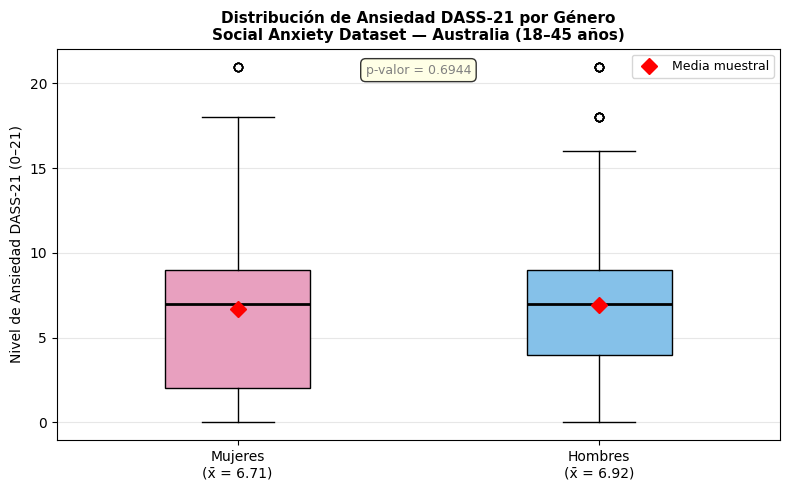

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

# Datos
data = [muestra_mujeres, muestra_hombres]
labels = [f'Mujeres\n(x̄ = {media_m:.2f})', f'Hombres\n(x̄ = {media_h:.2f})']

# Boxplot
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.4)

# Colores
bp['boxes'][0].set_facecolor('#E8A0BF')
bp['boxes'][1].set_facecolor('#85C1E9')
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

# Línea de la media como punto
ax.plot([1, 2], [media_m, media_h], 'D', color='red',
        markersize=8, zorder=5, label='Media muestral')

# Anotación p-valor
ax.text(1.5, max(muestra_mujeres.max(), muestra_hombres.max()) * 0.98,
        f'p-valor = {p_valor:.4f}',
        ha='center', fontsize=9, color='gray',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

ax.set_title('Distribución de Ansiedad DASS-21 por Género\nSocial Anxiety Dataset — Australia (18–45 años)',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Nivel de Ansiedad DASS-21 (0–21)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

CONCLUSION DE HIPOTESIS DE DOS VARIABLES

Con un t observado de -0.39, un t crítico de ±1.97 y un p-valor de 0.6944, no se rechaza la hipótesis nula con un nivel de significancia α=0.05. No existe evidencia estadística suficiente para afirmar que hay diferencia significativa en los niveles de ansiedad entre hombres (x̄=6.92) y mujeres (x̄=6.71) dentro del Social Anxiety Dataset. Este resultado es consistente con lo reportado por Stanton et al. (2020), donde tampoco se encontró diferencia significativa por género en población general australiana (p=0.108).

Ya en base a esta conclusion se puede comparar tambien con lo observado en el Stanton et al. (2020), donde alli se tomo en cuenta que no cambiaba el nivel de ansiedad de ninguno de los dos generos, esto podria explicarse con un gran factor que fue el tiempo en que se tomaron cada uno de los datos, hay que tener en cuenta que tanto este dataset como la fuente externa fueron tomados antes y durante la pandemia, este periodo de tiempo fue un factor importante que genero un estresor y fulminante en casos de ansiedad no solo en australia sino a nivel mundial, debido a las afectaciones psicologicas de estar encerrados, factores biologicos de muerte o enfermedad, factores socioeconomicos por esa epoca de cuarentena sin saber cuando terminaria, entonces esto podria ser clave para entender la igualdad en el nivel de ansiedad tanto en hombres como en mujeres. 